<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/human_activity_recognition_with_smartphones1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-activity-recognition-with-smartphones' dataset.
Path to dataset files: /kaggle/input/human-activity-recognition-with-smartphones


In [101]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [102]:
os.listdir(path)

['train.csv', 'test.csv']

In [103]:
df = pd.read_csv(os.path.join(path,'train.csv'))

In [104]:
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [105]:
df.shape

(7352, 563)

In [106]:
x = df.drop(['Activity', 'subject'], axis=1)
y = df['Activity']

In [107]:
x_train ,x_test ,y_train ,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [108]:
x.shape

(7352, 561)

In [109]:
knn = KNeighborsClassifier()

In [110]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [111]:
y_pred = knn.predict(x_test)

In [112]:
print(accuracy_score(y_test,y_pred))

0.9639700883752549


In [113]:
scaler = StandardScaler()

In [114]:
x_train_trf = scaler.fit_transform(x_train)
x_test_trf = scaler.transform(x_test)

In [124]:
x_train_trf.shape

(5881, 561)

In [167]:
pca = PCA(n_components=180)

In [168]:
x_train_pca = pca.fit_transform(x_train_trf)
x_test_pca = pca.transform(x_test_trf)

In [169]:
knn.fit(x_train_pca,y_train)


KNeighborsClassifier()

In [170]:
y_pred1 = knn.predict(x_test_pca)

In [171]:
print("tran pCA", accuracy_score(y_test,y_pred1))

tran pCA 0.9639700883752549


In [172]:
print(x_train_pca.shape)
# It must look like (7352, 561) -- meaning thousands of rows, not 2!

(5881, 180)


In [191]:
y_train.shape
y_train.unique()

array(['LAYING', 'WALKING_UPSTAIRS', 'STANDING', 'WALKING', 'SITTING',
       'WALKING_DOWNSTAIRS'], dtype=object)

--- Classification Report ---
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       280
           SITTING       0.94      0.88      0.91       262
          STANDING       0.89      0.95      0.92       276
           WALKING       0.98      1.00      0.99       247
WALKING_DOWNSTAIRS       1.00      0.98      0.99       206
  WALKING_UPSTAIRS       0.99      0.99      0.99       200

          accuracy                           0.96      1471
         macro avg       0.97      0.97      0.97      1471
      weighted avg       0.96      0.96      0.96      1471



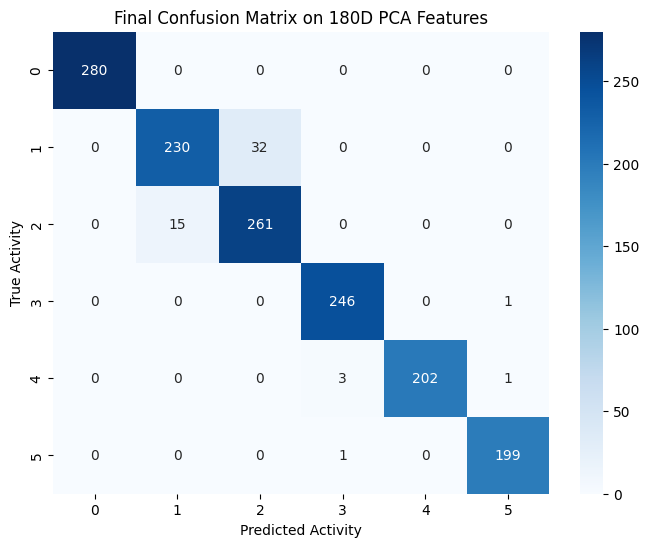

In [175]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print(classification_report(y_test, y_pred))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Final Confusion Matrix on 180D PCA Features')
plt.ylabel('True Activity')
plt.xlabel('Predicted Activity')
plt.show()

In [186]:
import pandas as pd
import plotly.express as px

# 1. Package your PCA array into a DataFrame
# Slicing the first 3 columns out of your 180D matrix
plot_df = pd.DataFrame(data=x_train_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
plot_df['Activity'] = y_train.values

# 2. Build the 3D Scatter Plot
fig = px.scatter_3d(
    plot_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Activity',
    title='Interactive 3D PCA Workspace',
    color_discrete_sequence=px.colors.qualitative.Vivid,
    opacity=0.6,
)

# 3. Optimize marker size for 5,881 points so it doesn't lag
fig.update_traces(marker=dict(size=4))

# 4. Explicitly force display
fig.show()